In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvY2FsdmluL2NvdXJzZS9haTEwMS9zcmM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/usr/lib/python3.12/importlib/_bootstrap.py": 1772540118.0, "/usr/lib/python3.12/importlib/_bootstrap_external.py": 1772540118.0, "/usr/lib/python3.12/zipimport.py": 1772540118.0, "/usr/lib/python3.12/codecs.py": 1772540118.0, "/usr/lib/python3.12/encodings/aliases.py": 1772540118.0, "/usr/lib/python3.12/encodings/__init__.py": 1772540118.0, "/usr/lib/python3.12/encodings/utf_8.py": 1772540118.0, "/usr/lib/python3.12/abc.py": 1772540118.0, "/usr/lib/python3.12/io.py": 1772540118.0, "/usr/lib/python3.12/stat.py": 1772540118.0, "/usr/lib/python3.12/_collections_abc.py": 1772540118.0, "/usr/lib/python3.12/genericpath.py": 1772540118.0, "/usr/lib/python3.12/posixpath.py": 1772540118.0, "/usr/lib/python3.12/os.py": 1772540118.0, "/usr/lib/python3.12/_sitebuiltins.py": 1772540118.0, "/usr/lib/python3/dist-packages/_distutils_hack/__init__.py": 1692360458.0, "/usr/lib/python3.12/types.py": 1772540118.0, "/usr/lib/python3.12/warnings.py": 1772540118.0, "/usr/lib/python3.12/importlib/__init__

In [2]:
import numpy as np
multi = np.array([
    [-1/1, -1/1, -1/1, -1/1,  1/1, -1/1, -1/1, -1/1, -1/1],
    [-1/2, -1/2,  1/2, -1/2, -1/2, -1/2,  1/2, -1/2, -1/2],
    [-1/3, -1/3,  1/3, -1/3,  1/3, -1/3,  1/3, -1/3, -1/3],
    [ 1/4, -1/4,  1/4, -1/4, -1/4, -1/4,  1/4, -1/4,  1/4],
    [ 1/5, -1/5,  1/5, -1/5,  1/5, -1/5,  1/5, -1/5,  1/5],
    [ 0/6,  3/6,  0/6,  3/6, -6/6,  3/6,  0/6,  3/6,  0/6],
])

In [3]:
rite = [0,0,1,0,1,0,1,0,0]
left = [1,0,0,0,1,0,0,0,1]

In [4]:
multi.shape

(6, 9)

In [5]:
for row in multi:
	print(rite * row)

[-0. -0. -1. -0.  1. -0. -1. -0. -0.]
[-0.  -0.   0.5 -0.  -0.5 -0.   0.5 -0.  -0. ]
[-0.         -0.          0.33333333 -0.          0.33333333 -0.
  0.33333333 -0.         -0.        ]
[ 0.   -0.    0.25 -0.   -0.25 -0.    0.25 -0.    0.  ]
[ 0.  -0.   0.2 -0.   0.2 -0.   0.2 -0.   0. ]
[ 0.  0.  0.  0. -1.  0.  0.  0.  0.]


In [6]:
for row in multi:
	print(sum(rite * row))

-1.0
0.5
1.0
0.25
0.6000000000000001
-1.0


In [7]:
for row in multi:
	print(1 <= sum(rite * row))

False
False
True
False
False
False


In [8]:
multi

array([[-1.        , -1.        , -1.        , -1.        ,  1.        ,
        -1.        , -1.        , -1.        , -1.        ],
       [-0.5       , -0.5       ,  0.5       , -0.5       , -0.5       ,
        -0.5       ,  0.5       , -0.5       , -0.5       ],
       [-0.33333333, -0.33333333,  0.33333333, -0.33333333,  0.33333333,
        -0.33333333,  0.33333333, -0.33333333, -0.33333333],
       [ 0.25      , -0.25      ,  0.25      , -0.25      , -0.25      ,
        -0.25      ,  0.25      , -0.25      ,  0.25      ],
       [ 0.2       , -0.2       ,  0.2       , -0.2       ,  0.2       ,
        -0.2       ,  0.2       , -0.2       ,  0.2       ],
       [ 0.        ,  0.5       ,  0.        ,  0.5       , -1.        ,
         0.5       ,  0.        ,  0.5       ,  0.        ]])

In [9]:
multi.transpose()

array([[-1.        , -0.5       , -0.33333333,  0.25      ,  0.2       ,
         0.        ],
       [-1.        , -0.5       , -0.33333333, -0.25      , -0.2       ,
         0.5       ],
       [-1.        ,  0.5       ,  0.33333333,  0.25      ,  0.2       ,
         0.        ],
       [-1.        , -0.5       , -0.33333333, -0.25      , -0.2       ,
         0.5       ],
       [ 1.        , -0.5       ,  0.33333333, -0.25      ,  0.2       ,
        -1.        ],
       [-1.        , -0.5       , -0.33333333, -0.25      , -0.2       ,
         0.5       ],
       [-1.        ,  0.5       ,  0.33333333,  0.25      ,  0.2       ,
         0.        ],
       [-1.        , -0.5       , -0.33333333, -0.25      , -0.2       ,
         0.5       ],
       [-1.        , -0.5       , -0.33333333,  0.25      ,  0.2       ,
         0.        ]])

In [10]:
rite @ multi.transpose()

array([-1.  ,  0.5 ,  1.  ,  0.25,  0.6 , -1.  ])

In [11]:
1 <= rite @ multi.transpose()

array([False, False,  True, False, False, False])

In [12]:
1 <= left @ multi.transpose()

array([False, False, False, False, False, False])

In [13]:
sum(left)

3

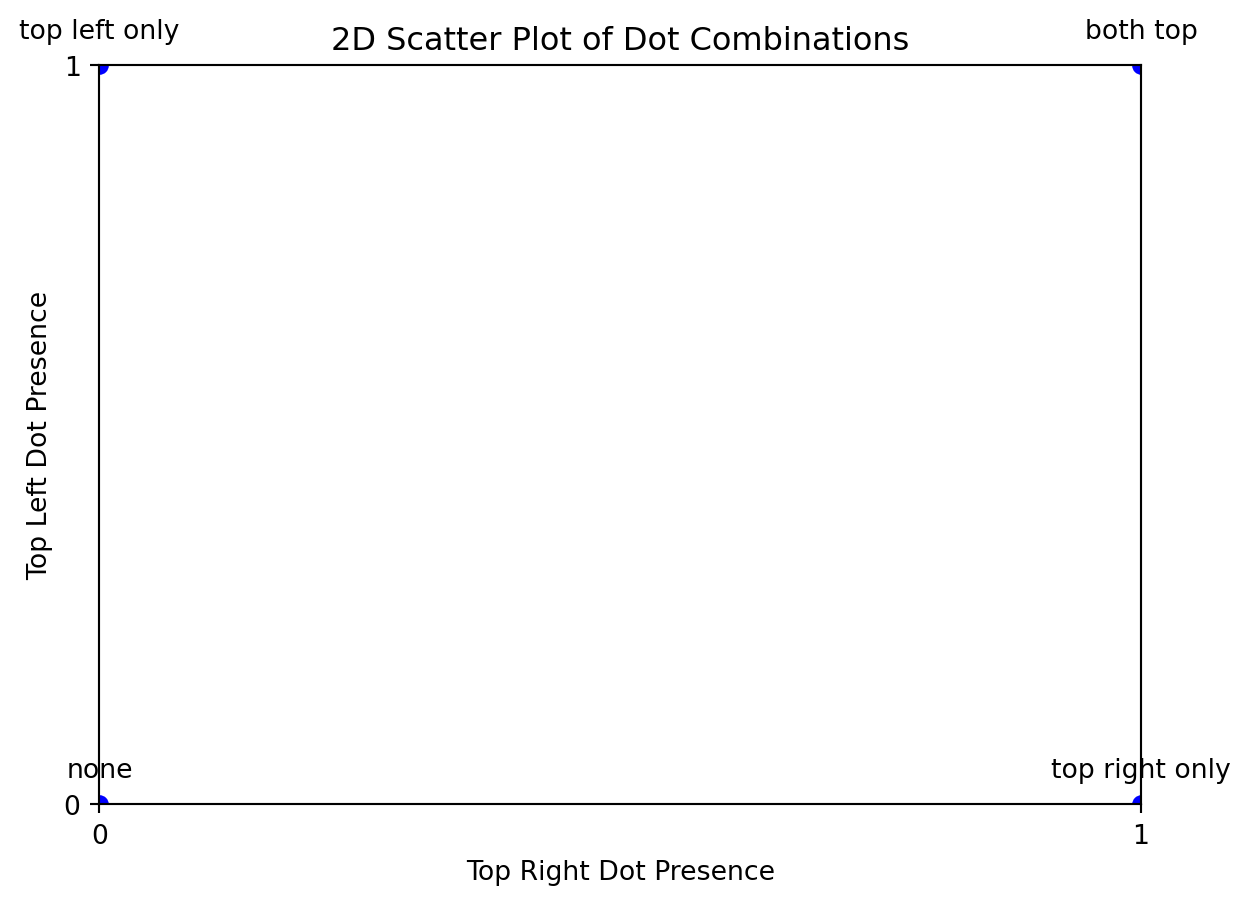

In [14]:
#| echo: false
import matplotlib.pyplot as plt

# Points and their labels
points = [(1, 0), (0, 1), (1, 1), (0, 0)]
labels = ["top right only", "top left only", "both top", "none"]

# Extract x and y coordinates
x_coords = [p[0] for p in points]
y_coords = [p[1] for p in points]

# Create the plot
plt.scatter(x_coords, y_coords, color='blue')

# Annotate each point
for i, label in enumerate(labels):
    plt.annotate(label, (x_coords[i], y_coords[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Set labels and title
plt.xlabel("Top Right Dot Presence")
plt.ylabel("Top Left Dot Presence")
plt.title("2D Scatter Plot of Dot Combinations")
plt.grid(True)
plt.xlim(-0, 1)
plt.ylim(-0, 1)

# Remove the grid
plt.grid(False)

# Set axes to only show integer points 0 and 1
plt.xticks([0, 1])
plt.yticks([0, 1])

# Save the plot
plt.savefig('scatter_plot.png')